In [ ]:
# =============================================================================
# BTC Volatility Forecasting — GJR-GARCH vs GARCH-LSTM
# Anti data-leakage | Diagnostica completa | In-sample & Out-of-sample
# Google Colab: esegui le celle nell'ordine indicato da # %%
# =============================================================================
#
# ARCHITETTURA ANTI-LEAKAGE:
# ─────────────────────────────────────────────────────────────────────────────
# • Target: RV5_lag = media mobile 5gg di ε²_{t-4..t} → TARGET al tempo t
#   è calcolato SOLO su passato rispetto a t+1, cioè si prevede
#   σ²_{t+1} usando RV5 centrato sul passato (nessun look-ahead).
#   In pratica: rv5[t] = mean(eps[t-4]²,...,eps[t]²) — tutti passati rispetto
#   alla previsione che facciamo al passo t per t+1. Allineamento:
#   X_input[t] → prevede rv5[t+1] (la volatilità del giorno successivo).
#
# • Feature on-chain: z-score rolling con shift(1) — usa solo info passata.
#
# • GARCH: parametri fittati SOLO su train; filtro causale su tutta la serie
#   (ogni σ²_t dipende solo da ε_{t-1}, σ²_{t-1} — nessun leakage).
#
# • GARCH-LSTM training: sequenza CONTINUA (niente campionamento random).
#   Il gradiente numerico viene calcolato sull'intera sequenza train.
#
# • Split temporale: 80% train | 10% val | 10% test. Nessun overlap.
# =============================================================================

In [ ]:
!pip install optuna openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy import stats
from IPython.display import display as ipy_display, Image as ipy_Image
import warnings, time
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

def show_fig(fig, filename):
    """Salva e mostra la figura inline su Colab."""
    plt.tight_layout()
    fig.savefig(filename, dpi=150, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    ipy_display(ipy_Image(filename))

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f7f7f7',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'grid.linestyle':   '--',
    'font.size':        10,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'legend.framealpha':0.85,
})

# ── Caricamento (Google Colab) ────────────────────────────────────────────────
from google.colab import files
print("Carica il file ip26_btconchain.xlsx")
uploaded  = files.upload()
DATA_PATH = list(uploaded.keys())[0]

df_raw = (pd.read_excel(DATA_PATH, parse_dates=['date'])
            .sort_values('date')
            .reset_index(drop=True))

# ── Log-rendimenti ε_t = log(p_t/p_{t-1}) × 100 ─────────────────────────────
log_ret = np.log(df_raw['BTC_CLOSE'] / df_raw['BTC_CLOSE'].shift(1)).dropna() * 100
eps     = log_ret.values.astype(np.float64)          # shape (N,)
dates   = df_raw['date'].iloc[1:].reset_index(drop=True)
N       = len(eps)

# ── Target: RV5 LAGGATO di 1 giorno (nessun look-ahead) ─────────────────────
# rv5[t] = mean(ε²[t-4], ..., ε²[t])  → target per PREVEDERE σ²[t+1]
# Quindi usiamo: X[t] → rv5_target[t+1]
# In pratica shift di -1 (tomorrow's realized vol spiegata da today's features)
rv5_raw  = pd.Series(eps**2).rolling(5, min_periods=5).mean().values
# Il target al giorno t è rv5_raw[t] (calcolato su ε[t-4..t]),
# ma lo assegniamo come "volatilità da prevedere al passo t+1"
# → allineamento: input[t], target[t] = rv5_raw[t] (realized vol del giorno t,
#   calcolata su passato puro, usata come proxy di σ²_t)
rv5 = rv5_raw.copy()   # target[t] = RV5 calcolata fino a t (solo passato)

# ── Feature on-chain: z-score rolling con shift(1) — ZERO leakage ────────────
ONCHAIN_COLS = ['TRVOU', 'ETRAV', 'TRFEE', 'HRATE', 'NADDU', 'NTRBL']
onchain_raw  = df_raw[ONCHAIN_COLS].iloc[1:].reset_index(drop=True)

def rolling_zscore(s, w=90):
    """Z-score calcolato su finestra rolling passata — nessun look-ahead."""
    mu  = s.rolling(w, min_periods=20).mean().shift(1)
    std = s.rolling(w, min_periods=20).std().shift(1)
    return ((s - mu) / (std + 1e-8)).fillna(0).clip(-5, 5)

onchain_feat = pd.DataFrame(index=onchain_raw.index)
for col in ['TRVOU', 'ETRAV', 'TRFEE', 'HRATE', 'NADDU']:
    # pct_change con shift(1) prima dello z-score → nessun leakage
    pct = onchain_raw[col].pct_change().shift(1).fillna(0).clip(-5, 5)
    onchain_feat[col] = rolling_zscore(pct)
onchain_feat['NTRBL'] = rolling_zscore(onchain_raw['NTRBL'])
X_on = onchain_feat.values.astype(np.float64)   # (N, 6)

# ── Split temporale 80/10/10 — nessun overlap ────────────────────────────────
i_val  = int(N * 0.80)
i_test = int(N * 0.90)

eps_tr, eps_vl, eps_te = eps[:i_val], eps[i_val:i_test], eps[i_test:]
rv5_tr, rv5_vl, rv5_te = rv5[:i_val], rv5[i_val:i_test], rv5[i_test:]
X_tr,   X_vl,   X_te   = X_on[:i_val], X_on[i_val:i_test], X_on[i_test:]
d_tr,   d_vl,   d_te   = dates[:i_val], dates[i_val:i_test], dates[i_test:]

print(f"\nN={N}  Train={i_val}  Val={i_test-i_val}  Test={N-i_test}")
print(f"Train: {d_tr.iloc[0].date()} → {d_tr.iloc[-1].date()}")
print(f"Val:   {d_vl.iloc[0].date()} → {d_vl.iloc[-1].date()}")
print(f"Test:  {d_te.iloc[0].date()} → {d_te.iloc[-1].date()}")

# ── Utilità comuni ────────────────────────────────────────────────────────────
def t_nll(eps_seq, s2_seq, nu=6.0):
    """Negative log-likelihood Student-t."""
    nu  = max(float(nu), 2.5)
    s2  = np.maximum(s2_seq, 1e-10)
    c   = gammaln((nu+1)/2) - gammaln(nu/2) - 0.5*np.log(np.pi*(nu-2))
    ll  = c - 0.5*np.log(s2) - ((nu+1)/2)*np.log(1 + eps_seq**2/((nu-2)*s2))
    return -np.nanmean(ll)

def metrics(y_true, y_pred, label=''):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred) | (y_pred <= 0))
    yt, yp = y_true[mask], y_pred[mask]
    mae    = np.mean(np.abs(yt - yp))
    rmse   = np.sqrt(np.mean((yt - yp)**2))
    r2     = 1 - np.sum((yt-yp)**2) / (np.sum((yt-yt.mean())**2) + 1e-10)
    qlik   = np.mean(np.log(yp) + yt/yp)   # QLIK standard (Patton 2011)
    if label:
        print(f"  {label:30s}  MAE={mae:.4f}  RMSE={rmse:.4f}  "
              f"R²={r2:.4f}  QLIK={qlik:.4f}")
    return dict(MAE=mae, RMSE=rmse, R2=r2, QLIK=qlik)

print("\nSetup completato.")


Carica il file ip26_btconchain.xlsx


Saving ip26_btconchain.xlsx to ip26_btconchain (5).xlsx

N=2374  Train=1899  Val=237  Test=238
Train: 2017-01-03 → 2024-04-12
Val:   2024-04-15 → 2025-03-11
Test:  2025-03-12 → 2026-02-06

Setup completato.


# [CELLA 1 — GJR-GARCH: fitting, diagnostica, in-sample & out-of-sample]

In [ ]:
print("="*65)
print("CELLA 1 — GJR-GARCH(1,1) con Student-t")
print("="*65)

# ── Filtro GJR-GARCH (causale — nessun leakage) ───────────────────────────────
def gjr_filter(eps_seq, omega, alpha, lam, beta, s2_init=None):
    """
    σ²_t = ω + (α + λ·I[ε_{t-1}<0])·ε²_{t-1} + β·σ²_{t-1}
    Completamente causale: σ²_t dipende solo da ε_{t-1} e σ²_{t-1}.
    """
    T  = len(eps_seq)
    s2 = np.empty(T)
    s2[0] = s2_init if s2_init is not None else np.var(eps_seq[:max(30,T//10)])
    for t in range(1, T):
        I      = 1.0 if eps_seq[t-1] < 0 else 0.0
        s2[t]  = omega + (alpha + lam*I)*eps_seq[t-1]**2 + beta*s2[t-1]
        s2[t]  = max(s2[t], 1e-8)
    return s2

# ── Fitting MLE su training set SOLTANTO ─────────────────────────────────────
def fit_gjr(eps_seq, nu_fixed=None):
    """
    Stima MLE di GJR-GARCH(1,1) + Student-t.
    Parametrizzazione vincolata con sigmoid/exp per garantire stazionarietà.
    """
    def obj(p):
        om  = np.exp(np.clip(p[0], -12, 4))
        al  = 0.30 / (1 + np.exp(-p[1]))
        la  = 0.30 / (1 + np.exp(-p[2]))
        be  = 0.98 / (1 + np.exp(-p[3]))
        nu  = (2.5 + np.exp(p[4])) if nu_fixed is None else nu_fixed
        if al + 0.5*la + be >= 0.9999: return 1e10
        s2  = gjr_filter(eps_seq, om, al, la, be)
        return t_nll(eps_seq, s2, nu)

    best_res, best_val = None, np.inf
    x0s = [[-4,-2,-2, 2,1.0],
            [-3,-2.5,-2.5,1.8,0.8],
            [-5,-3,-3,  2.2,1.2],
            [-4,-1,-3, 2.5,0.5]]
    for x0 in x0s:
        res = minimize(obj, x0, method='Nelder-Mead',
                       options={'maxiter':6000,'xatol':1e-7,'fatol':1e-7})
        if res.fun < best_val:
            best_val, best_res = res.fun, res

    p  = best_res.x
    return dict(
        omega = np.exp(np.clip(p[0],-12,4)),
        alpha = 0.30 / (1+np.exp(-p[1])),
        lam   = 0.30 / (1+np.exp(-p[2])),
        beta  = 0.98 / (1+np.exp(-p[3])),
        nu    = (2.5+np.exp(p[4])) if nu_fixed is None else nu_fixed,
        nll   = best_val
    )

t0 = time.time()
gp = fit_gjr(eps_tr)
fit_time = time.time() - t0

print(f"\n  Parametri stimati su training set:")
print(f"  ω={gp['omega']:.5f}  α={gp['alpha']:.4f}  "
      f"λ={gp['lam']:.4f}  β={gp['beta']:.4f}  ν={gp['nu']:.2f}")
print(f"  Persistenza (α + λ/2 + β) = {gp['alpha']+0.5*gp['lam']+gp['beta']:.4f}")
print(f"  Half-life volatilità shock ≈ "
      f"{np.log(0.5)/np.log(gp['alpha']+0.5*gp['lam']+gp['beta']):.1f} giorni")
print(f"  Fitting time: {fit_time:.1f}s")

# ── Filtro causale su tutta la serie (parametri da train, filtro passo-passo) ─
# CORRETTO: il filtro è causale, i parametri sono fissati da train.
# Val e test ricevono σ² propagato dal filtro — nessun leakage.
s2_full_g  = gjr_filter(eps, gp['omega'], gp['alpha'], gp['lam'], gp['beta'])
s2_tr_g    = s2_full_g[:i_val]
s2_vl_g    = s2_full_g[i_val:i_test]
s2_te_g    = s2_full_g[i_test:]

# Residui standardizzati z_t = ε_t / σ_t
z_tr_g = eps_tr / np.sqrt(s2_tr_g + 1e-10)
z_te_g = eps_te / np.sqrt(s2_te_g + 1e-10)

print("\nMetriche GJR-GARCH:")
m_g_tr = metrics(rv5_tr, s2_tr_g, 'In-sample  (train)')
m_g_vl = metrics(rv5_vl, s2_vl_g, 'Val')
m_g_te = metrics(rv5_te, s2_te_g, 'Out-of-sample (test)')

CELLA 1 — GJR-GARCH(1,1) con Student-t

  Parametri stimati su training set:
  ω=0.33957  α=0.0855  λ=0.0000  β=0.9144  ν=3.08
  Persistenza (α + λ/2 + β) = 0.9999
  Half-life volatilità shock ≈ 6931.1 giorni
  Fitting time: 12.2s

Metriche GJR-GARCH:
  In-sample  (train)              MAE=12.7034  RMSE=19.5445  R²=0.4710  QLIK=3.7028
  Val                             MAE=6.5675  RMSE=8.5793  R²=0.1931  QLIK=3.3010
  Out-of-sample (test)            MAE=5.0228  RMSE=5.8413  R²=-0.0270  QLIK=2.8515


# PLOT CELLA 1 — 4 pannelli: in-sample | oos | residui | QQ

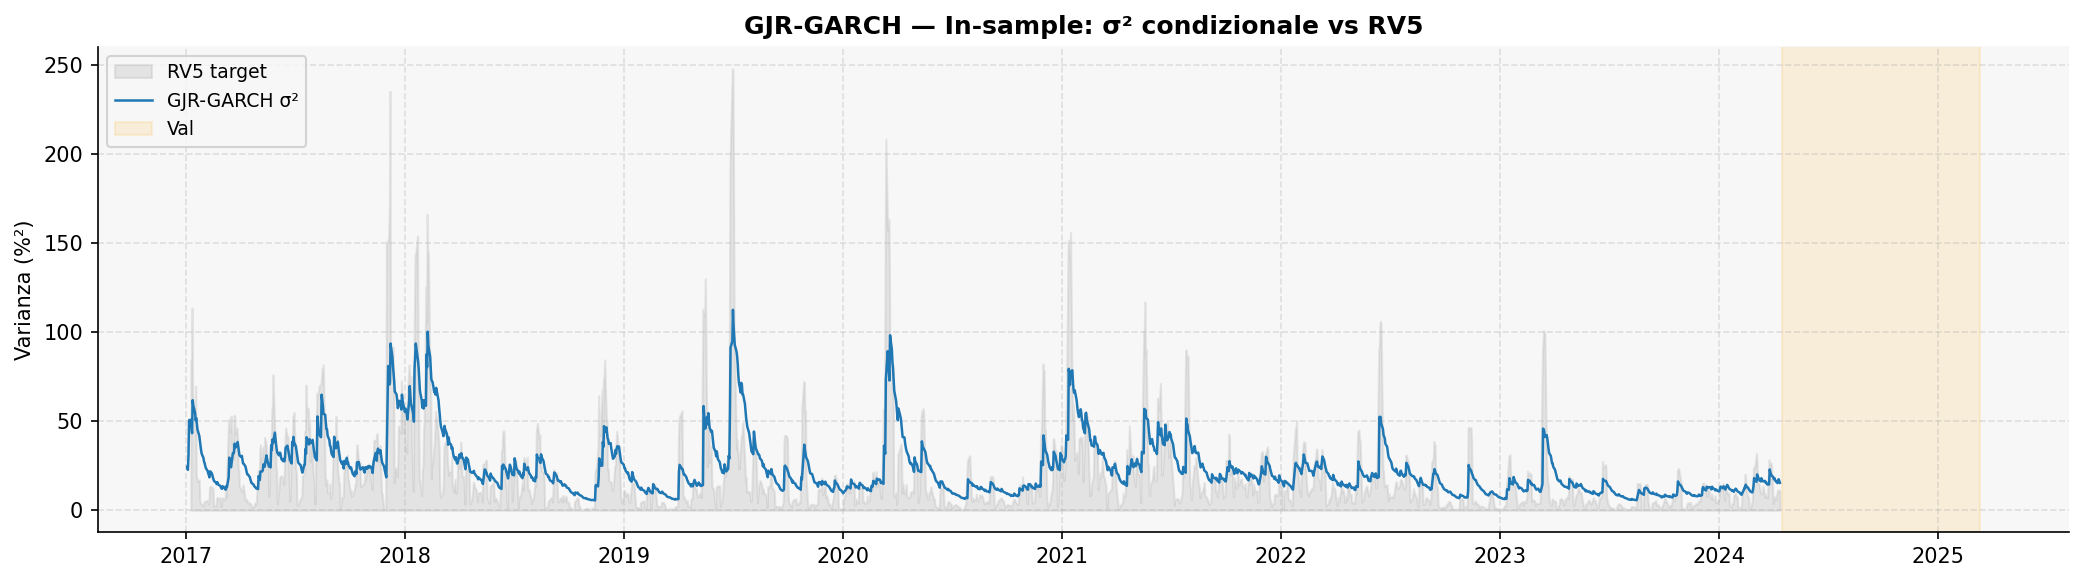

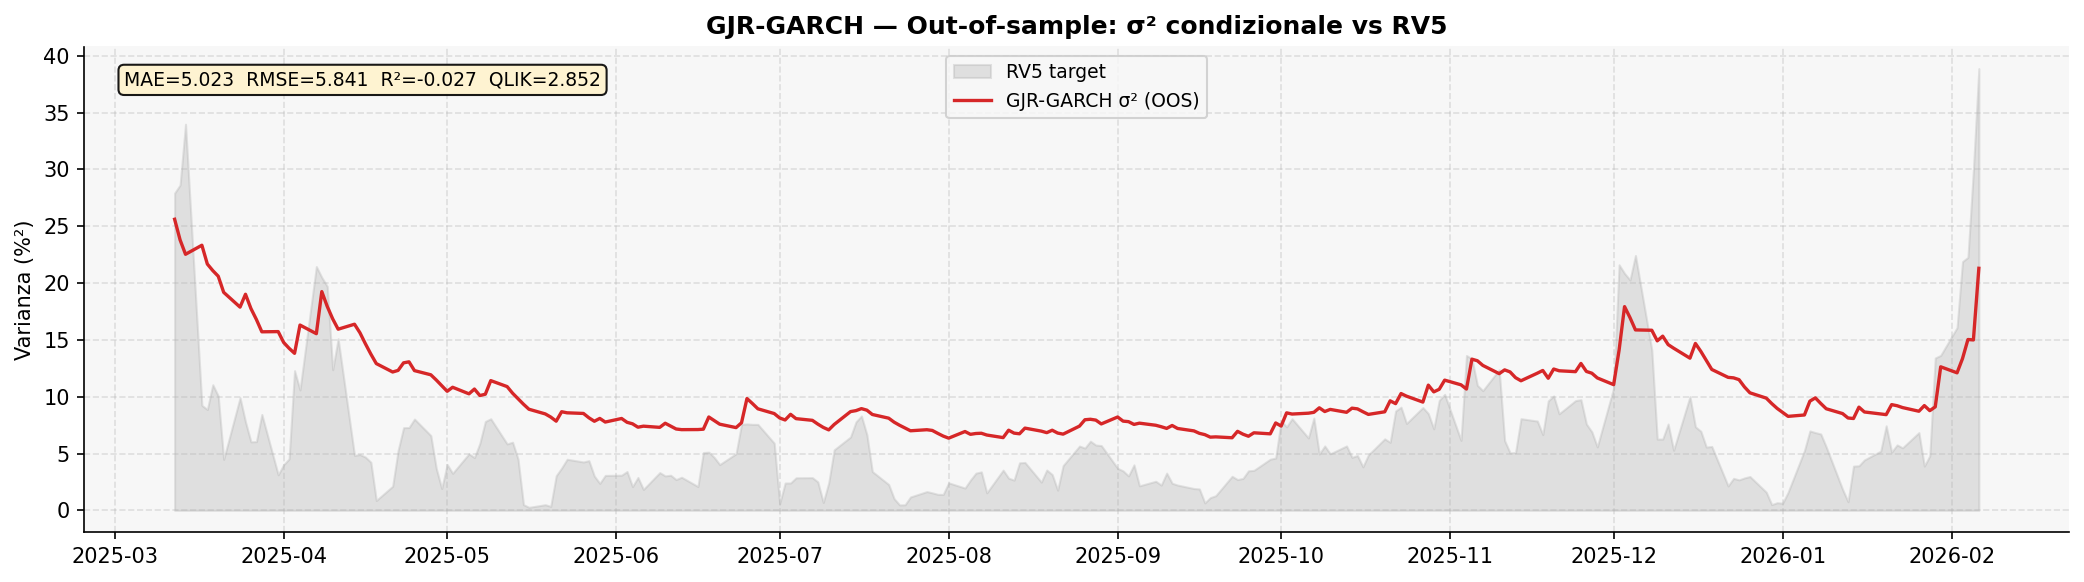

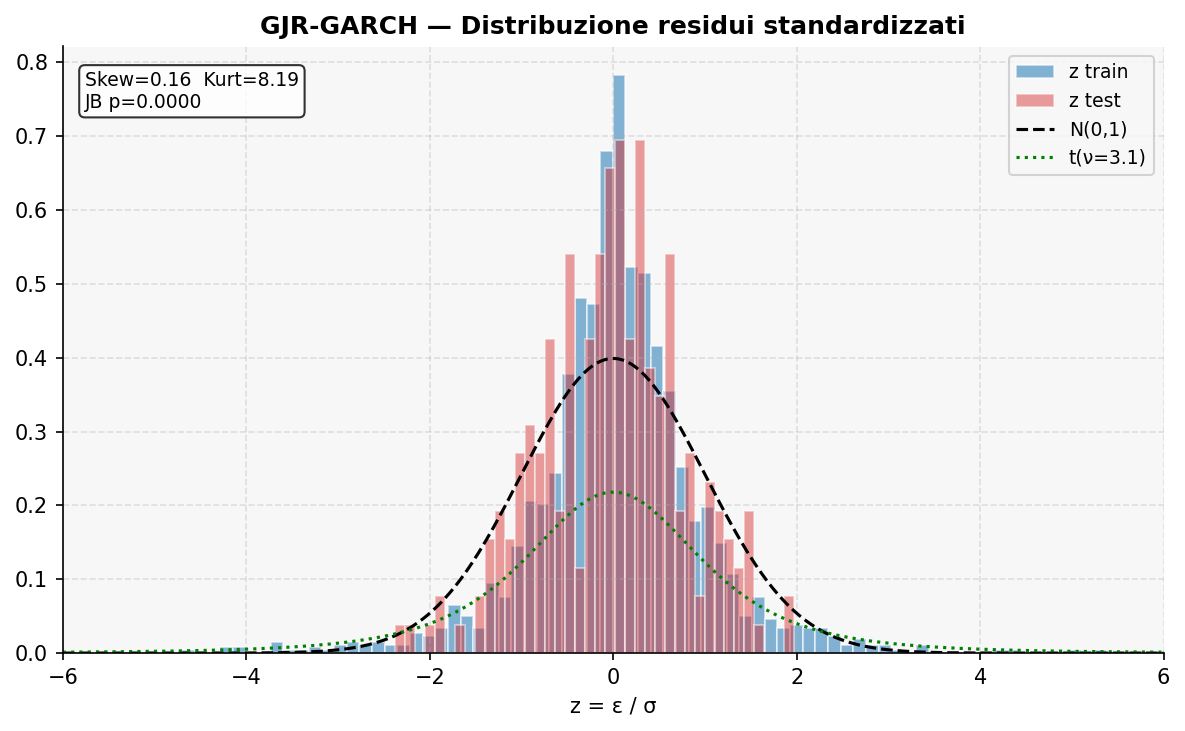

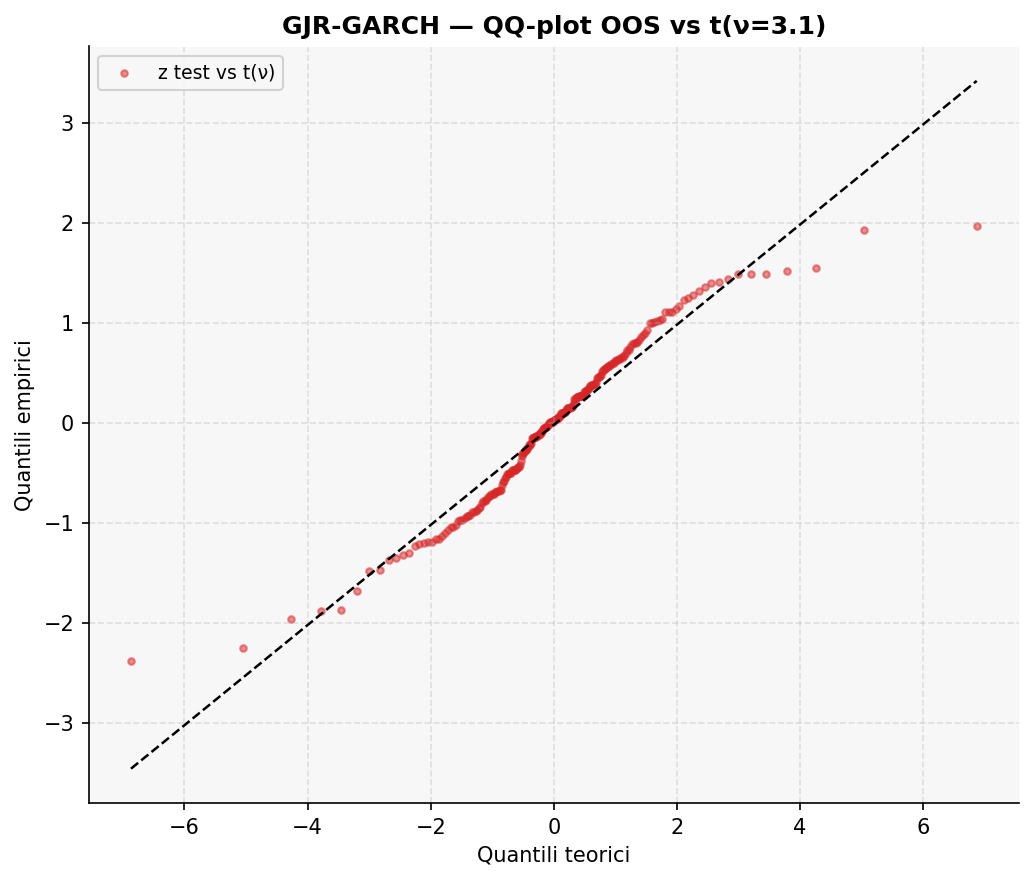

In [ ]:
nu_g = gp['nu']
xr   = np.linspace(-6, 6, 300)

# ── 1a: In-sample σ² vs RV5 ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(d_tr, rv5_tr, alpha=0.25, color='#aaaaaa', label='RV5 target')
ax.plot(d_tr, s2_tr_g, color='#1f77b4', lw=1.2, label='GJR-GARCH σ²')
ax.axvspan(d_vl.iloc[0], d_vl.iloc[-1], alpha=0.12, color='orange', label='Val')
ax.set_title('GJR-GARCH — In-sample: σ² condizionale vs RV5', fontweight='bold')
ax.set_ylabel('Varianza (%²)'); ax.legend(fontsize=9, loc='upper left')
show_fig(fig, 'c1a_insample.png')

# ── 1b: Out-of-sample σ² vs RV5 ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(d_te, rv5_te, alpha=0.3, color='#aaaaaa', label='RV5 target')
ax.plot(d_te, s2_te_g, color='#d62728', lw=1.6, label='GJR-GARCH σ² (OOS)')
ax.set_title('GJR-GARCH — Out-of-sample: σ² condizionale vs RV5', fontweight='bold')
ax.set_ylabel('Varianza (%²)'); ax.legend(fontsize=9)
ax.text(0.02, 0.92,
        f"MAE={m_g_te['MAE']:.3f}  RMSE={m_g_te['RMSE']:.3f}  "
        f"R²={m_g_te['R2']:.3f}  QLIK={m_g_te['QLIK']:.3f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#fff3cd', alpha=0.9))
show_fig(fig, 'c1b_oos.png')

# ── 1c: Distribuzione residui standardizzati ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(z_tr_g, bins=80, density=True, alpha=0.55, color='#1f77b4',
        edgecolor='white', label='z train')
ax.hist(z_te_g, bins=40, density=True, alpha=0.45, color='#d62728',
        edgecolor='white', label='z test')
ax.plot(xr, np.exp(-0.5*xr**2)/np.sqrt(2*np.pi), 'k--', lw=1.5, label='N(0,1)')
t_pdf = stats.t.pdf(xr, df=nu_g) * np.sqrt((nu_g-2)/nu_g)
ax.plot(xr, t_pdf, 'g:', lw=1.5, label=f't(ν={nu_g:.1f})')
ax.set_xlim(-6, 6)
ax.set_title('GJR-GARCH — Distribuzione residui standardizzati', fontweight='bold')
ax.set_xlabel('z = ε / σ'); ax.legend(fontsize=9)
sk = stats.skew(z_tr_g); ku = stats.kurtosis(z_tr_g, fisher=False)
jb = stats.jarque_bera(z_tr_g)
ax.text(0.02, 0.96, f"Skew={sk:.2f}  Kurt={ku:.2f}\nJB p={jb.pvalue:.4f}",
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
show_fig(fig, 'c1c_residui.png')

# ── 1d: QQ-plot vs Student-t ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
qq = stats.probplot(z_te_g, dist=stats.t, sparams=(nu_g,), plot=None)
ax.scatter(qq[0][0], qq[0][1], s=10, alpha=0.5, color='#d62728', label='z test vs t(ν)')
ax.plot(qq[0][0], qq[1][0]*qq[0][0]+qq[1][1], 'k--', lw=1.2)
ax.set_title(f'GJR-GARCH — QQ-plot OOS vs t(ν={nu_g:.1f})', fontweight='bold')
ax.set_xlabel('Quantili teorici'); ax.set_ylabel('Quantili empirici')
ax.legend(fontsize=9)
show_fig(fig, 'c1d_qq.png')

# [CELLA 2 — GARCH-LSTM + On-Chain: fitting, tuning, diagnostica]


In [ ]:
print("="*65)
print("CELLA 2 — GARCH-LSTM + On-Chain | PyTorch + CUDA + Optuna")
print("="*65)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n  Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

D_IN = 6   # numero feature on-chain

# ─────────────────────────────────────────────────────────────────────────────
# GARCH-LSTM in PyTorch
# ─────────────────────────────────────────────────────────────────────────────
# Architettura:
#   • Il kernel GJR-GARCH è differenziabile — i suoi parametri vengono
#     aggiornati via autograd esattamente come i gate weights.
#   • Il forward loop su T timestep è sequenziale (necessario per causalità)
#     ma gira interamente su GPU — le operazioni per timestep sono
#     matrix-vector product su GPU, molto più veloci del numpy puro.
#   • Nessun teacher forcing: σ²_{t-1} vero viene passato al passo successivo
#     (rolled sigma2), mantenendo la causalità del filtro GARCH.
# ─────────────────────────────────────────────────────────────────────────────

class GARCHKernel(nn.Module):
    """
    GJR-GARCH(1,1) differenziabile.
    Parametrizzazione con softplus/sigmoid per garantire:
      omega > 0, alpha,lam in (0,0.3), beta in (0,0.98)
      stazionarietà: alpha + lam/2 + beta < 1
    Warm-start dai parametri MLE del GJR-GARCH classico.
    """
    def __init__(self, gp_init=None):
        super().__init__()
        # Parametri in spazio non vincolato
        if gp_init is not None:
            om = float(gp_init['omega'])
            al = float(gp_init['alpha'])
            la = float(gp_init['lam'])
            be = float(gp_init['beta'])
            # inverse softplus per omega
            raw_om = np.log(np.expm1(om)) if om > 1e-4 else -4.0
            # inverse sigmoid scalato
            raw_al = np.log(max(al,1e-6) / max(0.30-al,1e-6))
            raw_la = np.log(max(la,1e-6) / max(0.30-la,1e-6))
            raw_be = np.log(max(be,1e-6) / max(0.98-be,1e-6))
        else:
            raw_om, raw_al, raw_la, raw_be = -2.0, -1.0, -1.0, 2.0

        self.raw_omega = nn.Parameter(torch.tensor(raw_om, dtype=torch.float32))
        self.raw_alpha = nn.Parameter(torch.tensor(raw_al, dtype=torch.float32))
        self.raw_lam   = nn.Parameter(torch.tensor(raw_la, dtype=torch.float32))
        self.raw_beta  = nn.Parameter(torch.tensor(raw_be, dtype=torch.float32))

    def get_params(self):
        omega = torch.nn.functional.softplus(self.raw_omega) + 1e-6
        alpha = 0.30 * torch.sigmoid(self.raw_alpha)
        lam   = 0.30 * torch.sigmoid(self.raw_lam)
        beta  = 0.98 * torch.sigmoid(self.raw_beta)
        # Clamp stazionarietà
        total = alpha + 0.5*lam + beta
        scale = torch.clamp(0.9998 / total, max=1.0)
        return omega, alpha*scale, lam*scale, beta*scale

    def forward(self, ep, sv):
        """ep: scalare, sv: scalare → σ²_t scalare"""
        omega, alpha, lam, beta = self.get_params()
        I = (ep < 0).float()
        return torch.clamp(omega + (alpha + lam*I)*ep**2 + beta*sv, min=1e-8)


class GARCHLSTMCell(nn.Module):
    """
    Singolo timestep del GARCH-LSTM.
    Input:  [ε_{t-1}, σ²_{t-1}, X_{t-1}]  (2 + D_IN scalari)
    Hidden: cella di memoria c (vettore H)
    Output: σ²_t
    """
    def __init__(self, hidden, d_in=D_IN, w_init=0.1, gp_init=None):
        super().__init__()
        self.H    = hidden
        inp_size  = 2 + d_in   # ε, σ², features

        # Gate LSTM (niente output gate — sostituito dal kernel GARCH)
        self.gate_f = nn.Linear(inp_size, hidden, bias=True)
        self.gate_i = nn.Linear(inp_size, hidden, bias=True)
        self.gate_c = nn.Linear(inp_size, hidden, bias=True)

        # Kernel GJR-GARCH differenziabile
        self.garch  = GARCHKernel(gp_init=gp_init)

        # Peso modulazione LSTM → inizializzato piccolo (warm start vicino a GARCH puro)
        self.w = nn.Parameter(torch.tensor(w_init, dtype=torch.float32))

        # Inizializzazione gate: bias forget gate a 1 (stabile all'inizio)
        nn.init.constant_(self.gate_f.bias, 1.0)
        nn.init.xavier_uniform_(self.gate_f.weight, gain=0.1)
        nn.init.xavier_uniform_(self.gate_i.weight, gain=0.1)
        nn.init.xavier_uniform_(self.gate_c.weight, gain=0.1)

    def forward(self, ep, sv, x_on, c):
        """
        ep:   (B,1)  ε_{t-1}
        sv:   (B,1)  σ²_{t-1}
        x_on: (B,D)  feature on-chain
        c:    (B,H)  cella memoria
        """
        inp = torch.cat([ep, sv, x_on], dim=-1)   # (B, 2+D)

        f   = torch.sigmoid(self.gate_f(inp))
        i   = torch.sigmoid(self.gate_i(inp))
        c_t = torch.tanh(   self.gate_c(inp))
        c   = f * c + i * c_t                      # (B, H)

        # Kernel GARCH — opera su ogni elemento del batch
        o_garch = self.garch(ep, sv)               # (B, 1)

        # Modulazione LSTM: σ²_t = σ²_garch × (1 + w·tanh(mean(c)))
        ctrl    = torch.tanh(c.mean(dim=-1, keepdim=True))  # (B,1)
        s2_out  = torch.clamp(o_garch * (1.0 + self.w * ctrl), min=1e-8)

        return s2_out, c


class GARCHLSTMModel(nn.Module):
    """
    Modello completo: esegue il loop temporale su sequenza di lunghezza T.
    Sequenza CONTINUA — nessun chunking — per rispettare la causalità.
    """
    def __init__(self, hidden, d_in=D_IN, w_init=0.1, gp_init=None):
        super().__init__()
        self.cell = GARCHLSTMCell(hidden, d_in, w_init, gp_init)
        self.H    = hidden

    def forward(self, eps_seq, X_seq, s2_init=None):
        """
        eps_seq: (T,)   — rendimenti
        X_seq:   (T, D) — feature on-chain
        Ritorna: sigma2: (T,)
        """
        T      = eps_seq.shape[0]
        s2_0   = s2_init if s2_init is not None else eps_seq[:30].var()
        s2_0   = s2_0.unsqueeze(0).unsqueeze(0)   # (1,1)
        c      = torch.zeros(1, self.H, device=eps_seq.device)
        s2_prev = s2_0

        s2_list = []
        for t in range(1, T):
            ep   = eps_seq[t-1].unsqueeze(0).unsqueeze(0)   # (1,1)
            x_on = X_seq[t-1].unsqueeze(0)                  # (1,D)
            s2_t, c = self.cell(ep, s2_prev, x_on, c)
            s2_list.append(s2_t)
            s2_prev = s2_t.detach()   # detach: tronca il grafo al passo precedente
                                       # (TBPTT-1 → stabile, memoria O(1))

        # Primo passo: usa s2_0 come placeholder
        s2_all = torch.cat([s2_0] + s2_list, dim=0).squeeze(-1)  # (T,)
        return s2_all


# ─────────────────────────────────────────────────────────────────────────────
# Loss function: T-NLL differenziabile in PyTorch
# ─────────────────────────────────────────────────────────────────────────────
def t_nll_torch(eps_seq, s2_seq, nu):
    """
    Negative log-likelihood Student-t — completamente differenziabile.
    nu: parametro scalare (float o tensor).
    """
    nu   = torch.clamp(nu, min=2.5)
    s2   = torch.clamp(s2_seq, min=1e-10)
    c    = (torch.lgamma((nu+1)/2) - torch.lgamma(nu/2)
            - 0.5*torch.log(torch.tensor(np.pi, device=s2.device)*(nu-2)))
    ll   = c - 0.5*torch.log(s2) - ((nu+1)/2)*torch.log(1 + eps_seq**2/((nu-2)*s2))
    return -ll.nanmean()


# ─────────────────────────────────────────────────────────────────────────────
# Preparazione tensori GPU
# ─────────────────────────────────────────────────────────────────────────────
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32, device=DEVICE)

eps_tr_t = to_tensor(eps_tr)
eps_vl_t = to_tensor(eps_vl)
eps_te_t = to_tensor(eps_te)
X_tr_t   = to_tensor(X_tr)
X_vl_t   = to_tensor(X_vl)
X_te_t   = to_tensor(X_te)

print("  Tensori su device:", DEVICE)


# ─────────────────────────────────────────────────────────────────────────────
# Training loop PyTorch con Adam + scheduler + early stopping
# ─────────────────────────────────────────────────────────────────────────────
def train_model(model, eps_tr_, X_tr_, eps_vl_, X_vl_,
                nu, lr=3e-3, n_epochs=200, patience=20, verbose=True):
    model.to(DEVICE)
    nu_t  = torch.tensor(nu, dtype=torch.float32, device=DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=patience//3, min_lr=1e-5
    )

    best_sd, best_vl, wait = None, np.inf, 0
    tr_hist, vl_hist = [], []

    for epoch in range(1, n_epochs+1):
        # ── Train step ────────────────────────────────────────────────────────
        model.train()
        optimizer.zero_grad()
        s2_tr = model(eps_tr_, X_tr_)
        loss  = t_nll_torch(eps_tr_, s2_tr, nu_t)
        loss.backward()
        # Gradient clipping per stabilità
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        # ── Val step ──────────────────────────────────────────────────────────
        if epoch % 10 == 0 or epoch == n_epochs:
            model.eval()
            with torch.no_grad():
                s2_vl = model(eps_vl_, X_vl_)
                vl    = t_nll_torch(eps_vl_, s2_vl, nu_t).item()
            tr_l = loss.item()
            scheduler.step(vl)
            tr_hist.append((epoch, tr_l))
            vl_hist.append((epoch, vl))

            if verbose:
                print(f"  ep={epoch:3d}  tr={tr_l:.4f}  vl={vl:.4f}  "
                      f"lr={optimizer.param_groups[0]['lr']:.1e}  wait={wait}")

            if vl < best_vl:
                best_vl = vl
                best_sd = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                wait    = 0
            else:
                wait += 1
                if wait >= patience:
                    if verbose: print(f"  Early stop a epoch {epoch}")
                    break

    model.load_state_dict(best_sd)
    return best_vl, tr_hist, vl_hist


# ─────────────────────────────────────────────────────────────────────────────
# Optuna TPE su GPU
# ─────────────────────────────────────────────────────────────────────────────
N_TRIALS   = 25
EPOCH_TUNE = 80

tuning_log = []

def optuna_objective(trial):
    H      = trial.suggest_categorical('hidden',  [16, 32, 64])
    w_init = trial.suggest_float('w_init',  0.01, 0.40, log=True)
    nu     = trial.suggest_float('nu',      4.0,  12.0)
    lr     = trial.suggest_float('lr',      5e-4,  1e-2, log=True)

    torch.manual_seed(trial.number * 17)
    model = GARCHLSTMModel(
        hidden=H, d_in=D_IN, w_init=w_init, gp_init=gp
    )
    vl, _, _ = train_model(
        model, eps_tr_t, X_tr_t, eps_vl_t, X_vl_t,
        nu=nu, lr=lr, n_epochs=EPOCH_TUNE, patience=10, verbose=False
    )

    # Salva il modello del trial per riutilizzarlo nel training finale se best
    with torch.no_grad():
        s2_tr_np = model(eps_tr_t, X_tr_t).cpu().numpy()
    tr_l = t_nll(eps_tr, s2_tr_np, nu)
    tuning_log.append(dict(
        trial=trial.number, H=H, w=w_init, nu=nu, lr=lr,
        val_loss=vl, tr_loss=tr_l
    ))
    print(f"  Trial {trial.number+1:02d}/{N_TRIALS}  "
          f"H={H:2d} w={w_init:.3f} ν={nu:.1f} lr={lr:.5f}  "
          f"val={vl:.4f}  tr={tr_l:.4f}")
    return vl

print(f"\n  Optuna TPE — {N_TRIALS} trials su {DEVICE}...")
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(optuna_objective, n_trials=N_TRIALS, show_progress_bar=False)

best_trial = study.best_trial
tdf = (pd.DataFrame(tuning_log)
         .sort_values('val_loss').reset_index(drop=True))

H_b    = int(best_trial.params['hidden'])
nu_b   = best_trial.params['nu']
lr_b   = best_trial.params['lr']
w_b    = best_trial.params['w_init']
print(f"\n  Best trial #{best_trial.number+1}:  "
      f"H={H_b}  w={w_b:.3f}  ν={nu_b:.1f}  lr={lr_b:.5f}  "
      f"val_loss={best_trial.value:.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# Training finale con best HP
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n  Training finale (200 epoch, patience=25)...")
torch.manual_seed(999)
model_best = GARCHLSTMModel(hidden=H_b, d_in=D_IN, w_init=w_b, gp_init=gp)
best_vl_final, tr_hist, vl_hist = train_model(
    model_best, eps_tr_t, X_tr_t, eps_vl_t, X_vl_t,
    nu=nu_b, lr=lr_b, n_epochs=200, patience=25, verbose=True
)

# ─────────────────────────────────────────────────────────────────────────────
# Previsioni su tutti i split (inference su CPU per semplicità)
# ─────────────────────────────────────────────────────────────────────────────
model_best.eval()
with torch.no_grad():
    s2_tr_gl = model_best(eps_tr_t, X_tr_t).cpu().numpy()
    s2_vl_gl = model_best(eps_vl_t, X_vl_t).cpu().numpy()
    s2_te_gl = model_best(eps_te_t, X_te_t).cpu().numpy()

z_tr_gl = eps_tr / np.sqrt(s2_tr_gl + 1e-10)
z_te_gl = eps_te / np.sqrt(s2_te_gl + 1e-10)

print("\nMetriche GARCH-LSTM:")
m_gl_tr = metrics(rv5_tr, s2_tr_gl, 'In-sample  (train)')
m_gl_vl = metrics(rv5_vl, s2_vl_gl, 'Val')
m_gl_te = metrics(rv5_te, s2_te_gl, 'Out-of-sample (test)')

# Parametri kernel GARCH appresi
om_l, al_l, la_l, be_l = [x.item() for x in model_best.cell.garch.get_params()]
w_l = model_best.cell.w.item()
print(f"\n  Kernel GARCH appresi: ω={om_l:.5f} α={al_l:.4f} "
      f"λ={la_l:.4f} β={be_l:.4f}")
print(f"  Persistenza: {al_l+0.5*la_l+be_l:.4f}")
print(f"  Peso modulazione LSTM: w={w_l:.4f}")


CELLA 2 — GARCH-LSTM + On-Chain | PyTorch + CUDA + Optuna

  Device: cuda
  GPU: NVIDIA A100-SXM4-40GB
  VRAM: 42.4 GB
  Tensori su device: cuda

  Optuna TPE — 25 trials su cuda...
  Trial 01/25  H=32 w=0.091 ν=5.2 lr=0.00080  val=2.5884  tr=2.7644
  Trial 02/25  H=32 w=0.136 ν=4.2 lr=0.00914  val=2.5916  tr=2.7582
  Trial 03/25  H=16 w=0.020 ν=6.4 lr=0.00241  val=2.5889  tr=2.7713
  Trial 04/25  H=64 w=0.017 ν=6.3 lr=0.00150  val=2.5887  tr=2.7710
  Trial 05/25  H=32 w=0.067 ν=8.7 lr=0.00057  val=2.5896  tr=2.7839
  Trial 06/25  H=16 w=0.331 ν=11.7 lr=0.00563  val=2.5910  tr=2.8001
  Trial 07/25  H=64 w=0.051 ν=5.0 lr=0.00220  val=2.5898  tr=2.7627
  Trial 08/25  H=32 w=0.115 ν=6.5 lr=0.00237  val=2.5878  tr=2.7742
  Trial 09/25  H=64 w=0.175 ν=11.5 lr=0.00730  val=2.5948  tr=2.7888
  Trial 10/25  H=32 w=0.021 ν=4.4 lr=0.00133  val=2.5917  tr=2.7613
  Trial 11/25  H=32 w=0.038 ν=9.1 lr=0.00374  val=2.5899  tr=2.7855
  Trial 12/25  H=32 w=0.105 ν=6.8 lr=0.00052  val=2.5873  tr=2.7753


# PLOT CELLA 2 — 6 pannelli

In [2]:
xr = np.linspace(-6, 6, 300)

# ── 2a: In-sample σ² ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(d_tr, rv5_tr, alpha=0.22, color='#aaaaaa', label='RV5 target')
ax.plot(d_tr, s2_tr_gl, color='#2ca02c', lw=1.2, label='GARCH-LSTM σ²')
ax.plot(d_tr, s2_tr_g,  color='#1f77b4', lw=0.8, ls='--', alpha=0.5, label='GJR-GARCH')
ax.axvspan(d_vl.iloc[0], d_vl.iloc[-1], alpha=0.10, color='orange', label='Val')
ax.set_title('GARCH-LSTM — In-sample: σ² condizionale vs RV5', fontweight='bold')
ax.set_ylabel('Varianza (%²)'); ax.legend(fontsize=9, loc='upper left')
show_fig(fig, 'c2a_insample.png')

# ── 2b: Out-of-sample σ² ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(d_te, rv5_te, alpha=0.25, color='#aaaaaa', label='RV5 target')
ax.plot(d_te, s2_te_gl, color='#2ca02c', lw=1.6, label='GARCH-LSTM (OOS)')
ax.plot(d_te, s2_te_g,  color='#d62728', lw=1.0, ls='--', alpha=0.65, label='GJR-GARCH (OOS)')
ax.set_title('GARCH-LSTM — Out-of-sample: σ² condizionale vs RV5', fontweight='bold')
ax.set_ylabel('Varianza (%²)'); ax.legend(fontsize=9)
ax.text(0.02, 0.92,
        f"GL: MAE={m_gl_te['MAE']:.3f} R²={m_gl_te['R2']:.3f} | "
        f"GJR: MAE={m_g_te['MAE']:.3f} R²={m_g_te['R2']:.3f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#e8f5e9', alpha=0.9))
show_fig(fig, 'c2b_oos.png')

# ── 2c: Optuna optimization history ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
trial_vals  = tdf.sort_values('trial')['val_loss'].values
best_so_far = np.minimum.accumulate(trial_vals)
ax.scatter(range(len(trial_vals)), trial_vals,
           c=['#2ca02c' if v == min(trial_vals) else '#aaaaaa' for v in trial_vals],
           s=50, zorder=3, label='Trial val loss')
ax.plot(range(len(trial_vals)), best_so_far,
        color='#d62728', lw=1.5, ls='--', label='Best so far')
ax.axhline(study.best_value, color='#2ca02c', lw=1, ls=':', alpha=0.7)
ax.annotate(f"Best={study.best_value:.4f}",
            xy=(best_trial.number, study.best_value),
            xytext=(best_trial.number+1, study.best_value+0.003),
            fontsize=9, color='#2ca02c',
            arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=1))
ax.set_xlabel('Trial'); ax.set_ylabel('Val T-NLL')
ax.set_title(f'Optuna TPE — Optimization history ({N_TRIALS} trials)', fontweight='bold')
ax.legend(fontsize=9)
show_fig(fig, 'c2c_optuna_history.png')

# ── 2d: HP importance ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
try:
    importance = optuna.importance.get_param_importances(study)
    hp_names   = list(importance.keys())
    hp_vals    = list(importance.values())
    colors_imp = ['#2ca02c' if v == max(hp_vals) else '#7ec8a0' for v in hp_vals]
    ax.barh(hp_names, hp_vals, color=colors_imp, height=0.5)
    ax.set_xlabel('Importance relativa')
    ax.set_title('Optuna — HP importance (FAnova)', fontweight='bold')
    for i, (name, val) in enumerate(zip(hp_names, hp_vals)):
        ax.text(val+0.005, i, f'{val:.3f}', va='center', fontsize=9)
except Exception:
    ax.text(0.5, 0.5, 'HP importance non disponibile\n(aumenta N_TRIALS)',
            ha='center', va='center', transform=ax.transAxes, fontsize=11)
    ax.set_title('HP importance', fontweight='bold')
show_fig(fig, 'c2d_hp_importance.png')

# ── 2e: Learning curve ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
if tr_hist:
    ep_c = [x[0] for x in tr_hist]
    ax.plot(ep_c, [x[1] for x in tr_hist], color='#2ca02c', lw=1.5, label='Train T-NLL')
    ax.plot(ep_c, [x[1] for x in vl_hist], color='#d62728', lw=1.5, ls='--', label='Val T-NLL')
ax.set_xlabel('Epoch'); ax.set_ylabel('T-NLL')
ax.set_title('GARCH-LSTM — Learning curve (training finale)', fontweight='bold')
ax.legend(fontsize=9)
show_fig(fig, 'c2e_learning_curve.png')

# ── 2f: Distribuzione residui standardizzati ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(z_tr_gl, bins=80, density=True, alpha=0.5, color='#2ca02c',
        edgecolor='white', label='z train')
ax.hist(z_te_gl, bins=40, density=True, alpha=0.5, color='#d62728',
        edgecolor='white', label='z test')
ax.plot(xr, np.exp(-0.5*xr**2)/np.sqrt(2*np.pi), 'k--', lw=1.5, label='N(0,1)')
t_pdf2 = stats.t.pdf(xr, df=nu_b) * np.sqrt((nu_b-2)/nu_b)
ax.plot(xr, t_pdf2, 'b:', lw=1.5, label=f't(ν={nu_b:.1f})')
ax.set_xlim(-6, 6); ax.legend(fontsize=9)
ax.set_title('GARCH-LSTM — Distribuzione residui standardizzati', fontweight='bold')
sk2 = stats.skew(z_tr_gl); ku2 = stats.kurtosis(z_tr_gl, fisher=False)
ax.text(0.02, 0.96, f"Skew={sk2:.2f}  Kurt={ku2:.2f}",
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
show_fig(fig, 'c2f_residui.png')

NameError: name 'np' is not defined

# [CELLA 3 — Confronto completo: in-sample, OOS, diagnostica comparata]


In [ ]:
print("="*65)
print("CELLA 3 — Confronto GJR-GARCH vs GARCH-LSTM")
print("="*65)

results = {
    'GJR-GARCH':  {'train': m_g_tr,  'val': m_g_vl,  'test': m_g_te},
    'GARCH-LSTM': {'train': m_gl_tr, 'val': m_gl_vl, 'test': m_gl_te},
}

# ── Tabella riepilogativa ─────────────────────────────────────────────────────
print(f"\n  {'Modello':22s} {'Split':6s}  {'MAE':>8s}  {'RMSE':>8s}  "
      f"{'R²':>8s}  {'QLIK':>8s}")
print("  " + "-"*65)
for mn, splits in results.items():
    for sn, m in splits.items():
        tag = 'In-sample' if sn=='train' else ('Val' if sn=='val' else 'OOS')
        print(f"  {mn:22s} {tag:9s}  {m['MAE']:8.4f}  {m['RMSE']:8.4f}  "
              f"{m['R2']:8.4f}  {m['QLIK']:8.4f}")
    print("  " + "-"*65)

print("\n  Miglioramento GARCH-LSTM vs GJR-GARCH (OOS):")
for met in ['MAE', 'RMSE', 'QLIK']:
    d = (m_g_te[met] - m_gl_te[met]) / (abs(m_g_te[met])+1e-10) * 100
    arrow = '↓ migliore' if d > 0 else '↑ peggiore'
    print(f"    Δ {met:5s}: {d:+.1f}%  {arrow}")
print(f"    Δ R²:    {m_gl_te['R2']-m_g_te['R2']:+.4f} punti")

# ── Dirichlet loss test (Mincer-Zarnowitz regression) ────────────────────────
def mz_regression(rv5_true, s2_pred, label):
    """
    Regressione Mincer-Zarnowitz: RV5 = a + b·σ² + u
    Un modello perfetto ha a≈0, b≈1, R²→1.
    """
    mask = ~(np.isnan(rv5_true) | np.isnan(s2_pred))
    y = rv5_true[mask]; x = s2_pred[mask]
    X = np.column_stack([np.ones(len(x)), x])
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    y_hat = X @ b
    r2 = 1 - np.sum((y-y_hat)**2) / (np.sum((y-y.mean())**2)+1e-10)
    print(f"  MZ [{label:20s}]: α={b[0]:.4f} (0?)  β={b[1]:.4f} (1?)  R²={r2:.4f}")
    return b[0], b[1], r2

print("\n  Mincer-Zarnowitz (OOS) — test di unbiasedness:")
mz_regression(rv5_te, s2_te_g,  'GJR-GARCH')
mz_regression(rv5_te, s2_te_gl, 'GARCH-LSTM')

CELLA 3 — Confronto GJR-GARCH vs GARCH-LSTM

  Modello                Split        MAE      RMSE        R²      QLIK
  -----------------------------------------------------------------
  GJR-GARCH              In-sample   12.7034   19.5445    0.4710    3.7028
  GJR-GARCH              Val          6.5675    8.5793    0.1931    3.3010
  GJR-GARCH              OOS          5.0228    5.8413   -0.0270    2.8515
  -----------------------------------------------------------------
  GARCH-LSTM             In-sample   10.3074   19.0057    0.4998    3.6284
  GARCH-LSTM             Val          4.9266    7.5348    0.3776    3.2361
  GARCH-LSTM             OOS          3.6092    4.8126    0.3029    2.7791
  -----------------------------------------------------------------

  Miglioramento GARCH-LSTM vs GJR-GARCH (OOS):
    Δ MAE  : +28.1%  ↓ migliore
    Δ RMSE : +17.6%  ↓ migliore
    Δ QLIK : +2.5%  ↓ migliore
    Δ R²:    +0.3299 punti

  Mincer-Zarnowitz (OOS) — test di unbiasedness:
  MZ [GJR

(np.float64(-8.444850314568178),
 np.float64(1.8064541808384467),
 np.float64(0.5069524191265076))

# PLOT CELLA 3 — 6 pannelli di confronto

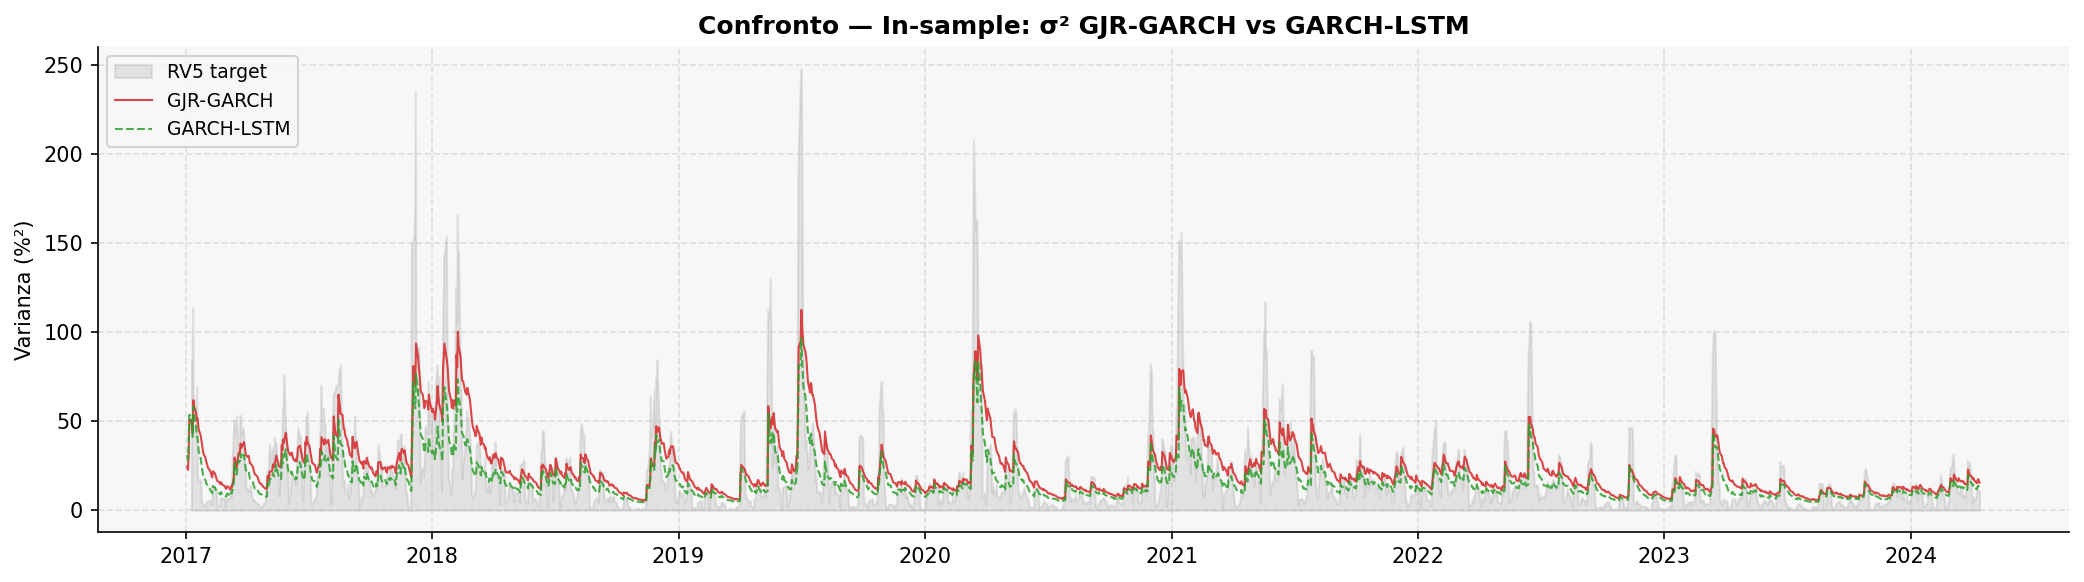

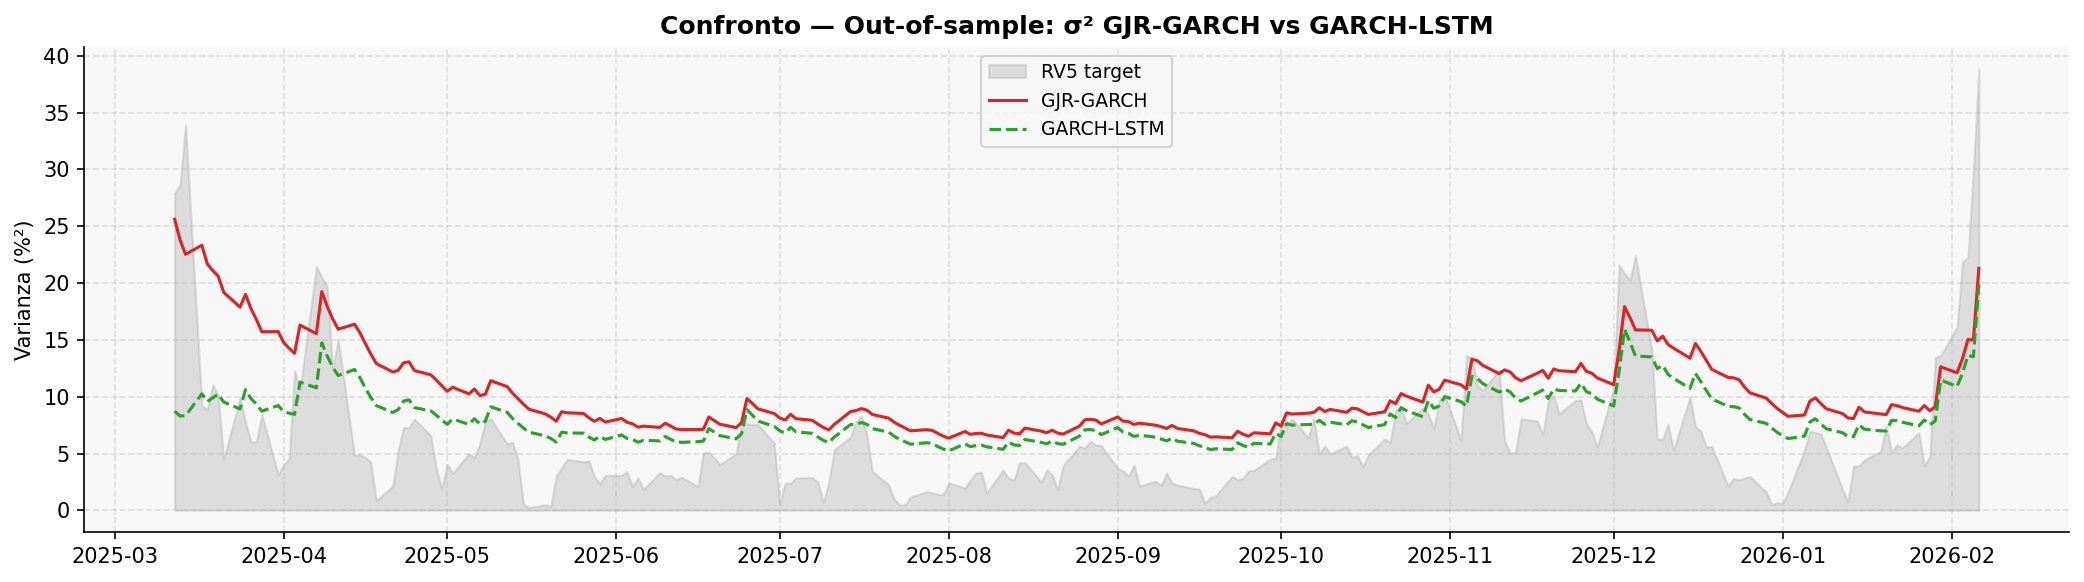

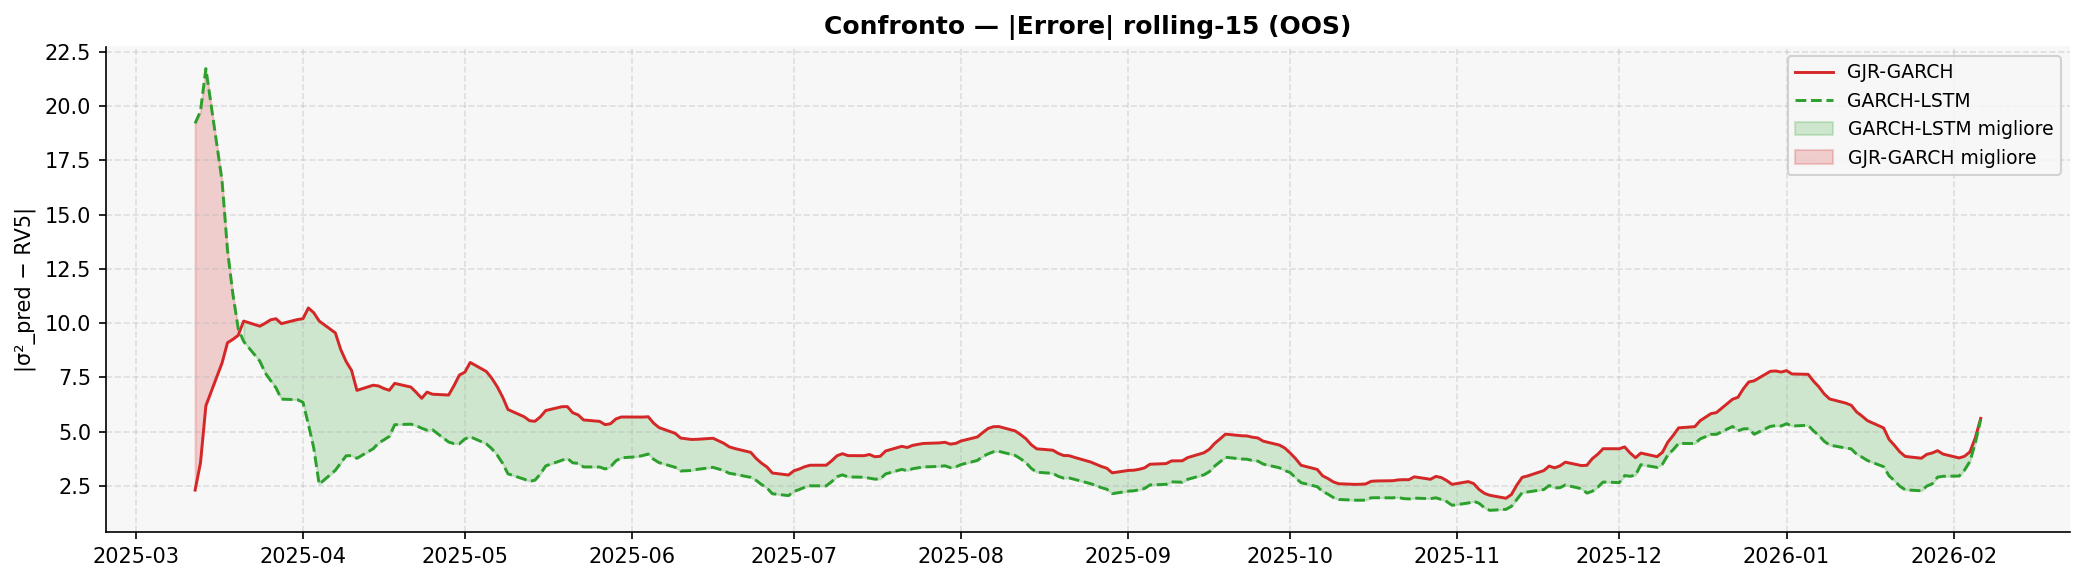

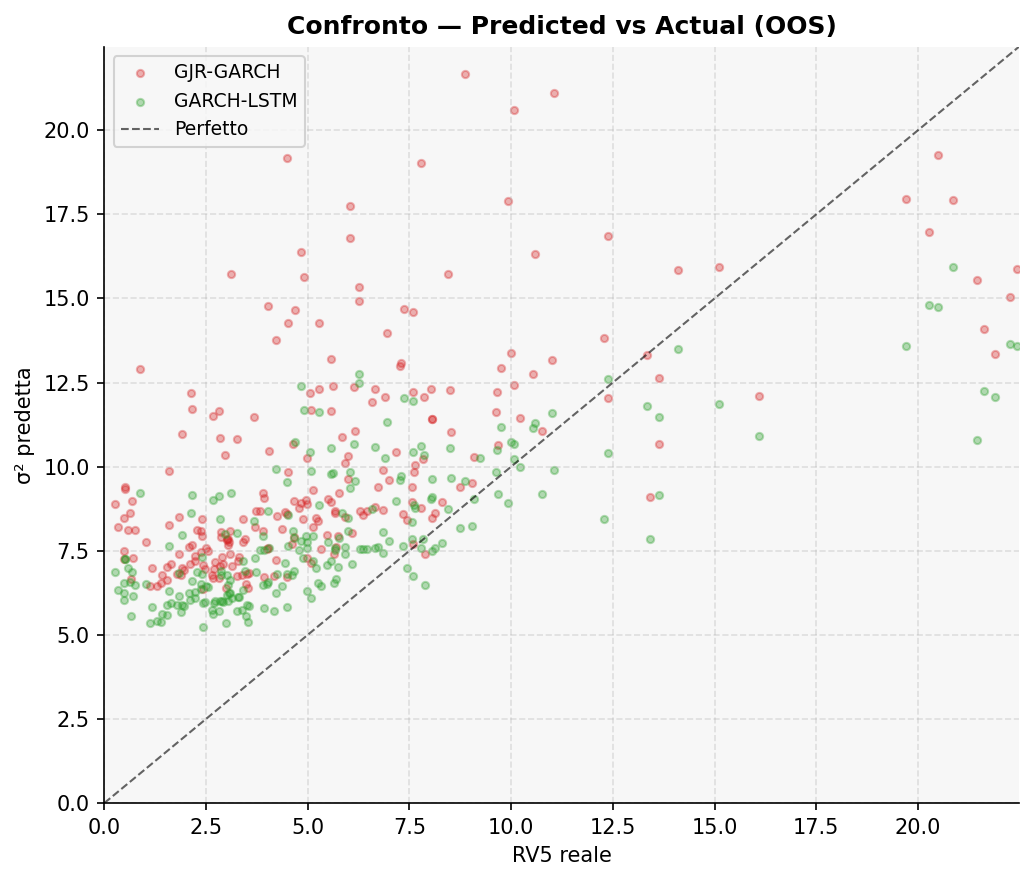

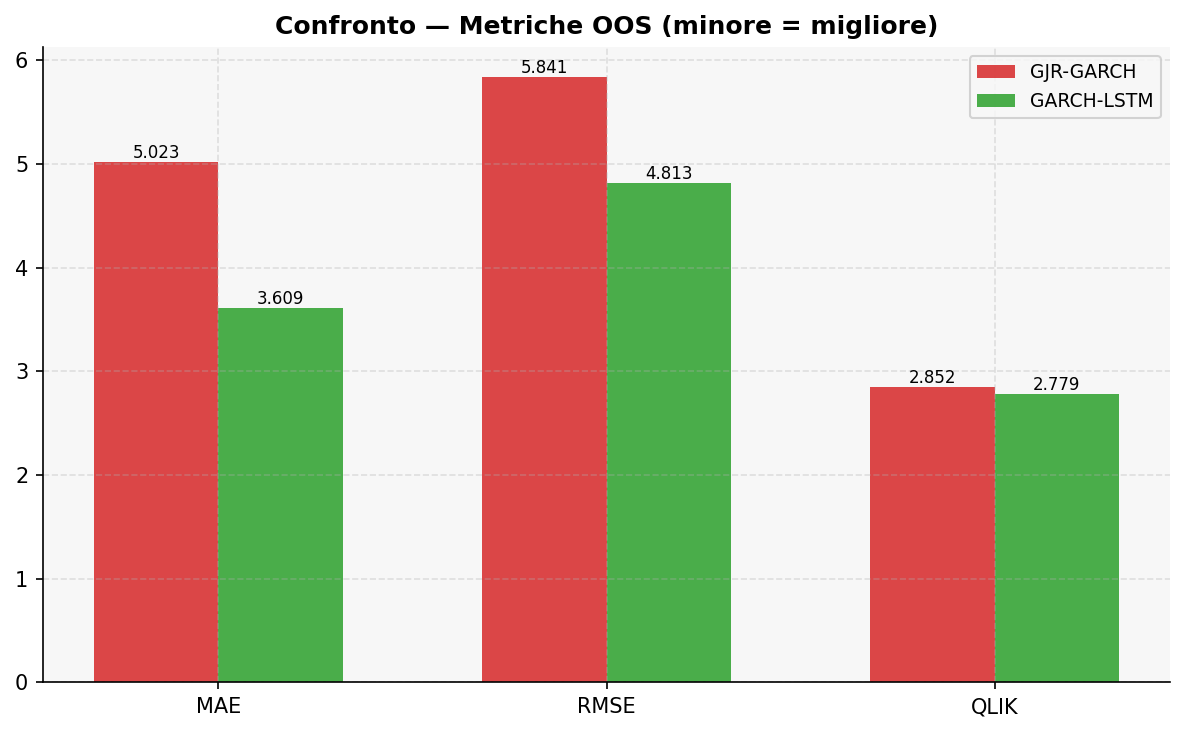

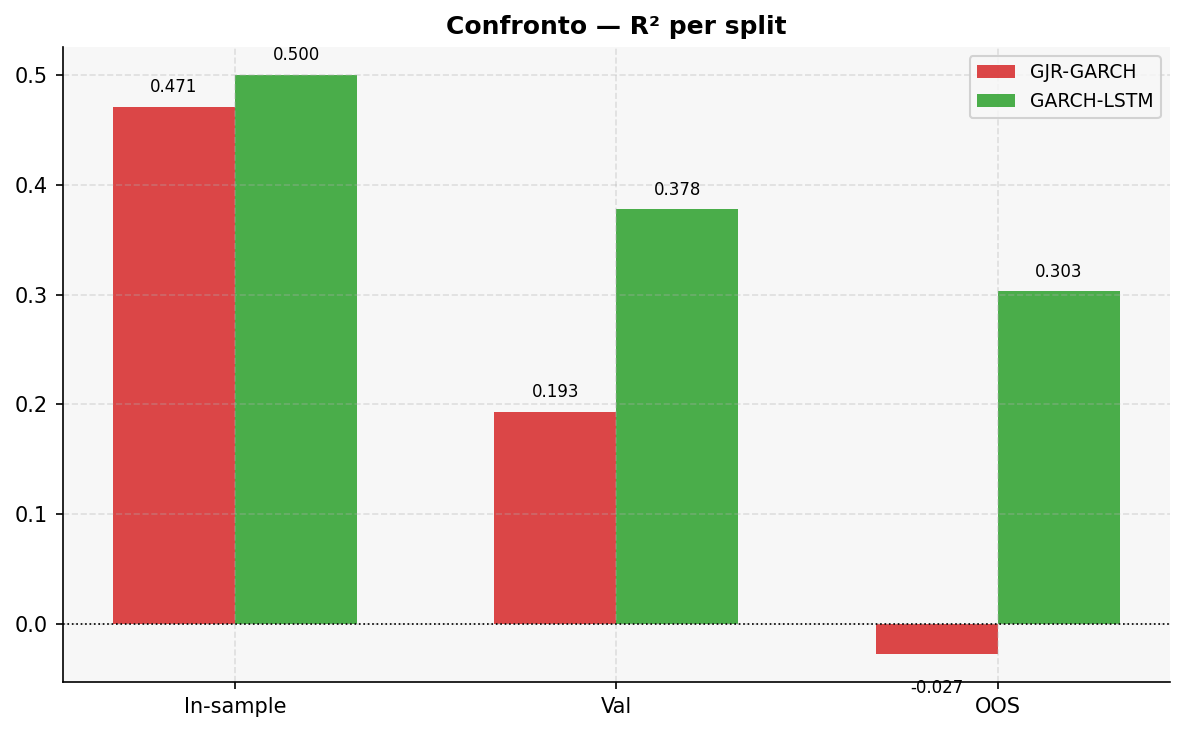

In [ ]:
COLORS = {'GJR-GARCH': '#d62728', 'GARCH-LSTM': '#2ca02c'}

# ── 3a: In-sample σ² confronto ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(d_tr, rv5_tr, alpha=0.18, color='gray', label='RV5 target')
ax.plot(d_tr, s2_tr_g,  color=COLORS['GJR-GARCH'],  lw=1.0, alpha=0.85, label='GJR-GARCH')
ax.plot(d_tr, s2_tr_gl, color=COLORS['GARCH-LSTM'], lw=1.0, alpha=0.85, ls='--', label='GARCH-LSTM')
ax.set_title('Confronto — In-sample: σ² GJR-GARCH vs GARCH-LSTM', fontweight='bold')
ax.set_ylabel('Varianza (%²)'); ax.legend(fontsize=9, loc='upper left')
show_fig(fig, 'c3a_insample.png')

# ── 3b: OOS σ² confronto ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(d_te, rv5_te, alpha=0.22, color='gray', label='RV5 target')
ax.plot(d_te, s2_te_g,  color=COLORS['GJR-GARCH'],  lw=1.5, label='GJR-GARCH')
ax.plot(d_te, s2_te_gl, color=COLORS['GARCH-LSTM'], lw=1.5, ls='--', label='GARCH-LSTM')
ax.set_title('Confronto — Out-of-sample: σ² GJR-GARCH vs GARCH-LSTM', fontweight='bold')
ax.set_ylabel('Varianza (%²)'); ax.legend(fontsize=9)
show_fig(fig, 'c3b_oos.png')

# ── 3c: Errore assoluto rolling OOS ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ae_g  = pd.Series(np.abs(rv5_te - s2_te_g)).rolling(15, min_periods=1).mean().values
ae_gl = pd.Series(np.abs(rv5_te - s2_te_gl)).rolling(15, min_periods=1).mean().values
ax.plot(d_te, ae_g,  color=COLORS['GJR-GARCH'],  lw=1.4, label='GJR-GARCH')
ax.plot(d_te, ae_gl, color=COLORS['GARCH-LSTM'], lw=1.4, ls='--', label='GARCH-LSTM')
ax.fill_between(d_te, ae_g, ae_gl,
                where=(ae_gl < ae_g),  alpha=0.2, color='#2ca02c', label='GARCH-LSTM migliore')
ax.fill_between(d_te, ae_g, ae_gl,
                where=(ae_gl >= ae_g), alpha=0.2, color='#d62728', label='GJR-GARCH migliore')
ax.set_title('Confronto — |Errore| rolling-15 (OOS)', fontweight='bold')
ax.set_ylabel('|σ²_pred − RV5|'); ax.legend(fontsize=9)
show_fig(fig, 'c3c_errore_rolling.png')

# ── 3d: Scatter predicted vs actual OOS ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
mask = ~np.isnan(rv5_te)
ax.scatter(rv5_te[mask], s2_te_g[mask],  s=12, alpha=0.35,
           color=COLORS['GJR-GARCH'],  label='GJR-GARCH')
ax.scatter(rv5_te[mask], s2_te_gl[mask], s=12, alpha=0.35,
           color=COLORS['GARCH-LSTM'], label='GARCH-LSTM')
lim = np.percentile(np.concatenate([rv5_te[mask], s2_te_g[mask],
                                     s2_te_gl[mask]]), 98) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=1, alpha=0.6, label='Perfetto')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel('RV5 reale'); ax.set_ylabel('σ² predetta')
ax.set_title('Confronto — Predicted vs Actual (OOS)', fontweight='bold')
ax.legend(fontsize=9)
show_fig(fig, 'c3d_scatter.png')

# ── 3e: Barre metriche OOS ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
met_names = ['MAE', 'RMSE', 'QLIK']
x = np.arange(3); bw = 0.32
b1_ = ax.bar(x-bw/2, [m_g_te[m]  for m in met_names], bw,
             color=COLORS['GJR-GARCH'],  label='GJR-GARCH',  alpha=0.85)
b2_ = ax.bar(x+bw/2, [m_gl_te[m] for m in met_names], bw,
             color=COLORS['GARCH-LSTM'], label='GARCH-LSTM', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(met_names)
ax.set_title('Confronto — Metriche OOS (minore = migliore)', fontweight='bold')
ax.legend(fontsize=9)
for bar in list(b1_)+list(b2_):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
show_fig(fig, 'c3e_metriche.png')

# ── 3f: R² per split ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
splits_lab = ['In-sample', 'Val', 'OOS']
splits_key = ['train', 'val', 'test']
x2 = np.arange(3)
r2_g  = [results['GJR-GARCH'][s]['R2']  for s in splits_key]
r2_gl = [results['GARCH-LSTM'][s]['R2'] for s in splits_key]
ax.bar(x2-bw/2, r2_g,  bw, color=COLORS['GJR-GARCH'],  label='GJR-GARCH',  alpha=0.85)
ax.bar(x2+bw/2, r2_gl, bw, color=COLORS['GARCH-LSTM'], label='GARCH-LSTM', alpha=0.85)
ax.axhline(0, color='k', lw=0.8, ls=':')
ax.set_xticks(x2); ax.set_xticklabels(splits_lab)
ax.set_title('Confronto — R² per split', fontweight='bold')
ax.legend(fontsize=9)
for v, xi in zip(r2_g+r2_gl, list(x2-bw/2)+list(x2+bw/2)):
    yoff = 0.01 if v >= 0 else -0.04
    ax.text(xi, v+yoff, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
show_fig(fig, 'c3f_r2.png')

In [ ]:
# ── Riepilogo finale ──────────────────────────────────────────────────────────
print("\n" + "="*65)
print("RIEPILOGO")
print("="*65)
print(f"  GJR-GARCH:  ω={gp['omega']:.5f} α={gp['alpha']:.4f} "
      f"λ={gp['lam']:.4f} β={gp['beta']:.4f} ν={gp['nu']:.2f}")
print(f"  GARCH-LSTM: ω={om_l:.5f} α={al_l:.4f} λ={la_l:.4f} β={be_l:.4f} "
      f"w={w_l:.4f}")
print(f"  Best HP: H={H_b}  w_init={best_trial.params['w_init']:.3f}  "
      f"ν={nu_b:.1f}  lr={lr_b:.4f}")
print(f"  Feature: {ONCHAIN_COLS}")
print("="*65)


RIEPILOGO
  GJR-GARCH:  ω=0.33957 α=0.0855 λ=0.0000 β=0.9144 ν=3.08
  GARCH-LSTM: ω=0.33611 α=0.0869 λ=0.0000 β=0.9129 w=0.0692
  Best HP: H=32  w_init=0.084  ν=7.0  lr=0.0020
  Feature: ['TRVOU', 'ETRAV', 'TRFEE', 'HRATE', 'NADDU', 'NTRBL']
